In [ ]:
# Install dependencies
!pip install transformers datasets

In [ ]:

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from transformers import get_scheduler
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from torch.optim import AdamW
from google.colab import drive

# Load data
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

# Encode labels
encoder = LabelEncoder()
train_df['label'] = encoder.fit_transform(train_df['sentiment'])
test_df['label'] = encoder.transform(test_df['sentiment'])

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len)
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = SentimentDataset(train_df['tweet'], train_df['label'], tokenizer)
test_dataset = SentimentDataset(test_df['tweet'], test_df['label'], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)


In [ ]:
# ✅ Custom BERT model with hidden layer = 100
class CustomBERTClassifier(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # Hidden layer = 100 nodes
        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 100),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(100, num_labels)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output

        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}

# Initialize model
model = CustomBERTClassifier(num_labels=2)

# Optimizer & scheduler
optimizer = AdamW(model.parameters(), lr=2e-5)

num_training_steps = len(train_loader) * 3
lr_scheduler = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
model.train()
for epoch in range(3):
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )

        loss = outputs["loss"]
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask']
        )

        preds = torch.argmax(outputs["logits"], dim=1)

        correct += (preds == batch['labels']).sum().item()
        total += batch['labels'].size(0)

print("Test Accuracy:", correct / total)

Epoch 2: 100%|██████████| 350/350 [01:55<00:00,  3.02it/s, loss=0.0222]


Test Accuracy: 0.9707142857142858


In [ ]:
model.eval()

print("\nSample Predictions:\n")

count = 0
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask']
        )

        preds = torch.argmax(outputs["logits"], dim=1)

        for i in range(len(preds)):
            text = test_df.iloc[count]['tweet']
            actual = encoder.inverse_transform([batch['labels'][i].cpu().item()])[0]
            predicted = encoder.inverse_transform([preds[i].cpu().item()])[0]

            print(f"Text: {text}")
            print(f"Actual: {actual} | Predicted: {predicted}")
            print("-" * 80)

            count += 1
            if count >= 5:  # show 5 examples
                break
        if count >= 5:
            break


Sample Predictions:

Text: is my #child old enough to learn #windsurfing?  #children #windsurfing #waterspos #fun   #training #spos
Actual: Negative | Predicted: Negative
--------------------------------------------------------------------------------
Text: i got flowers! #spoilt #relationshipgoals   
Actual: Negative | Predicted: Negative
--------------------------------------------------------------------------------
Text: the #truth abt #police &amp;  #maga  #audiblechannels 
Actual: Positive | Predicted: Negative
--------------------------------------------------------------------------------
Text: my favourite shop!ððð¼ðð  #fashion #victoriassecret #perfectbody #collection #smile #beautyâ¦ 
Actual: Negative | Predicted: Negative
--------------------------------------------------------------------------------
Text: belting #5minutes on my way to see @user in #funnygirl because you're my @user  
Actual: Negative | Predicted: Negative
---------------------------------

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...


Epoch 0
Train Loss: 0.5070, Train Acc: 0.8792
Val Loss: 0.6238, Val Acc: 0.9482


Epoch 1: 100%|██████████| 315/315 [01:00<00:00,  5.20it/s, acc=0.938, loss=1.41]



Epoch 1
Train Loss: 0.3396, Train Acc: 0.9702
Val Loss: 0.5148, Val Acc: 0.9375


Epoch 2: 100%|██████████| 315/315 [01:04<00:00,  4.89it/s, acc=1, loss=0.0208]



Epoch 2
Train Loss: 0.1904, Train Acc: 0.9841
Val Loss: 0.6944, Val Acc: 0.9482


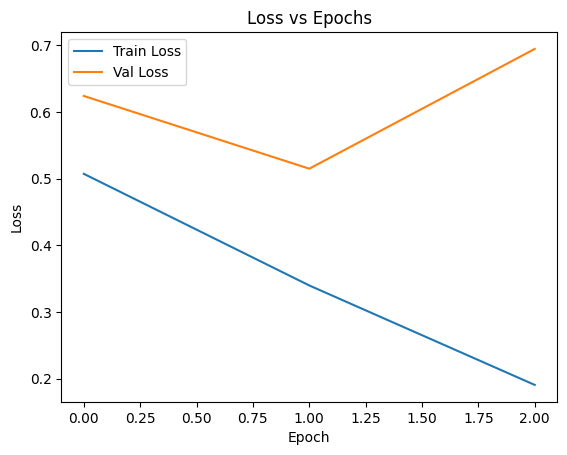

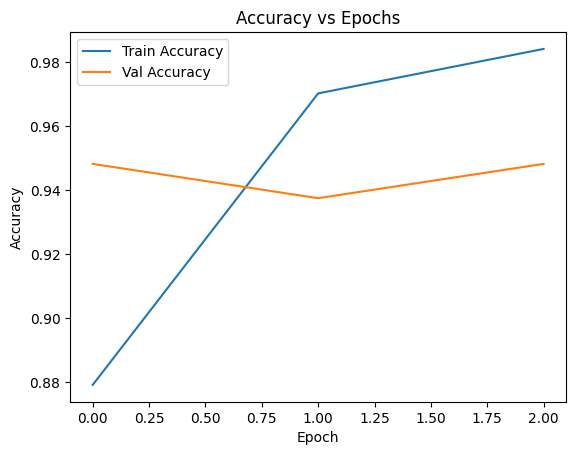


Test Accuracy: 0.965

Sample Predictions:

Text: is my #child old enough to learn #windsurfing?  #children #windsurfing #waterspos #fun   #training #spos
Actual: Negative | Predicted: Negative
--------------------------------------------------------------------------------
Text: i got flowers! #spoilt #relationshipgoals   
Actual: Negative | Predicted: Negative
--------------------------------------------------------------------------------
Text: the #truth abt #police &amp;  #maga  #audiblechannels 
Actual: Positive | Predicted: Positive
--------------------------------------------------------------------------------
Text: my favourite shop!ððð¼ðð  #fashion #victoriassecret #perfectbody #collection #smile #beautyâ¦ 
Actual: Negative | Predicted: Negative
--------------------------------------------------------------------------------
Text: belting #5minutes on my way to see @user in #funnygirl because you're my @user  
Actual: Negative | Predicted: Negative
-----------

In [ ]:

import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from torch.optim import AdamW
from google.colab import drive

# =========================
# Load Dataset
# =========================
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

# Encode labels
encoder = LabelEncoder()
train_df['label'] = encoder.fit_transform(train_df['sentiment'])
test_df['label'] = encoder.transform(test_df['sentiment'])

# Train-validation split
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

# =========================
# Tokenizer
# =========================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# =========================
# Dataset Class
# =========================
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len)
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Datasets
train_dataset = SentimentDataset(train_df['tweet'], train_df['label'], tokenizer)
val_dataset = SentimentDataset(val_df['tweet'], val_df['label'], tokenizer)
test_dataset = SentimentDataset(test_df['tweet'], test_df['label'], tokenizer)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# =========================
# Custom BERT Model (Hidden layer = 100)
# =========================
class CustomBERTClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 100),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(100, num_labels)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output

        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}

# =========================
# Class Weights (for imbalance)
# =========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# =========================
# Training Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomBERTClassifier(num_labels=2)
model.to(device)
class_weights = class_weights.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 3
num_training_steps = len(train_loader) * epochs

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# =========================
# Metrics Storage
# =========================
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

def compute_accuracy(preds, labels):
    return (preds == labels).sum().item() / len(labels)

# =========================
# Training Loop
# =========================
best_val_acc = 0

for epoch in range(epochs):
    model.train()
    total_loss, total_acc = 0, 0

    loop = tqdm(train_loader)

    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )

        loss = outputs["loss"]
        logits = outputs["logits"]

        preds = torch.argmax(logits, dim=1)
        acc = compute_accuracy(preds, batch['labels'])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        total_acc += acc

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item(), acc=acc)

    avg_train_loss = total_loss / len(train_loader)
    avg_train_acc = total_acc / len(train_loader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    # =========================
    # Validation
    # =========================
    model.eval()
    val_loss, val_acc = 0, 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['labels']
            )

            loss = outputs["loss"]
            logits = outputs["logits"]

            preds = torch.argmax(logits, dim=1)
            acc = compute_accuracy(preds, batch['labels'])

            val_loss += loss.item()
            val_acc += acc

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    print(f"\nEpoch {epoch}")
    print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

    # Save best model
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), "/content/best_model.pt")

# =========================
# Plot Graphs
# =========================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# =========================
# Test Evaluation
# =========================
model.eval()
correct, total = 0, 0

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask']
        )

        preds = torch.argmax(outputs["logits"], dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

        correct += (preds == batch['labels']).sum().item()
        total += batch['labels'].size(0)

print("\nTest Accuracy:", correct / total)

# =========================
# Show Sample Predictions
# =========================
print("\nSample Predictions:\n")

for i in range(5):
    text = test_df.iloc[i]['tweet']
    actual = encoder.inverse_transform([all_labels[i]])[0]
    predicted = encoder.inverse_transform([all_preds[i]])[0]

    print(f"Text: {text}")
    print(f"Actual: {actual} | Predicted: {predicted}")
    print("-" * 80)